In [1]:
import os
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader, get_worker_info, random_split
import tarfile
import json
from PIL import Image
import torchvision.transforms as transforms
import torch
import torch.optim as optim  
import math
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import seaborn as sns

/home/oscar/miniconda3/envs/torch_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Definint rutes als conjunts d'entrenament i test

In [2]:
Train_Json = 'TVMCE/meta/train.json'
Test_Json = 'TVMCE/meta/test.json'

Train_Videos = 'TVMCE/train'
Test_Videos = 'TVMCE/test'

## Definint timm backbone, dimensions, i nom del model

In [3]:
Timm_Backbone = "mobilenetv3_small_100.lamb_in1k"
dimensions_model = 1024

image_width = 224
image_height = 224

model_name = "MobileNet_Multicamera_Model"

In [4]:
backbone = timm.create_model(
            Timm_Backbone,
            pretrained=True,
            num_classes=0,  # remove classifier nn.Linear
        )

backbone.num_features

576

## Configurant Random Seed

In [5]:
torch.manual_seed(42)
random.seed(42)

## Inicialitzant GPU

In [6]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

GPU: NVIDIA GeForce RTX 3060 Laptop GPU is available.
cuda


## Creant Dataset Class

In [7]:
class MultiCameraDataset(Dataset):
    def __init__(self, json_path, videos_dir, transform, max_offset = 500):
        # carregant el json
        with open(json_path) as f:
            all_data = json.load(f)
        
        #Filtrant aquells que tingin boundary = 1
        self.metadata = []
        max_cam_id = 0
        for entry in all_data:
            if entry.get('boundary') == 1:

                more_than_max = False

                c_f = entry["CAMFrame"]
                
                for past_f in entry["outputList"]:
                    if ((c_f - past_f) >= max_offset) or ((c_f - past_f) < 0):
                        more_than_max = True
                        break
                
                if more_than_max == False:
                    self.metadata.append(entry)
                
                    camera_ids = [int(c.replace("CAM", "")) for c in entry["CAMList"]]
                    camera_ids.append(int(entry["currentCam"].replace("CAM", "")))
                    m = max(camera_ids)
                    if max_cam_id < m:
                        max_cam_id = m

        print(f"Maximum camera ID: {max_cam_id}")
            
        self.frames_dir = videos_dir
        self.transform = transform
        self.maximum_offset = max_offset

    def __len__(self):
        return len(self.metadata)

    def transform_camera_ID_to_tensor(self, cameraID):
        # Extreu el número del Id de la càmera i converteix-lo a tensor
        cam_id_number = cameraID.replace("CAM", "")

        cam_id_tensor = torch.tensor(int(cam_id_number) - 1, dtype=torch.long)

        return cam_id_tensor

    def load_frame(self, 
                   video_name, frame, cameras,
                   past_frames, curr_camera
                  ):

        candidate_frames_to_tensor = []
        camera_Ids_tensor = []

        # Carrega tots els frames candidats
        for camera in cameras:
                
            #member = tar_file.getmember(os.path.join(video_name, camera, f"{frame}.jpg"))
            path = os.path.join(self.frames_dir,video_name, camera, f"{frame}.jpg")
            
            # Carrega imatge
            img = Image.open(path).convert("RGB")

            candidate_frames_to_tensor.append(self.transform(img))
                

            # Transforma el Id de la camera a tensor i afegeix-lo a la llista
            camera_Ids_tensor.append(self.transform_camera_ID_to_tensor(camera))

        
        past_f, offsets = self.load_multiple_frames(video_name, past_frames, curr_camera, frame)

        return candidate_frames_to_tensor, camera_Ids_tensor, past_f, offsets


    def load_multiple_frames(self, video_name, frames, camera, current_frame):

        frames_to_tensor = []

        past_frame_offsets = []

        # Carrega els frames llistats
        for frame in sorted(frames):
            # Calcula el frame offset
            offset = current_frame - frame
            # Mira si el offset és menor al màxim permés.
            if offset < self.maximum_offset:
                past_frame_offsets.append(torch.tensor(offset))
                #member = tarfile_opened.getmember(os.path.join(video_name, camera, f"{frame}.jpg"))
                path = os.path.join(self.frames_dir,video_name, camera, f"{frame}.jpg")
                
                
                img = Image.open(path).convert("RGB")

    
                frames_to_tensor.append(self.transform(img))

        return frames_to_tensor, past_frame_offsets

    
    def __getitem__(self, idx):
        
        ## Recupera variables del json.

        entry = self.metadata[idx]

        video = entry["videoID"]

        frame = entry["CAMFrame"]

        previous_frames = entry["outputList"]

        current_camera = entry["currentCam"]

        candidate_cameras = entry["CAMList"]

        selected_camera = entry["selectCAM"]

        ## Recol·lecta els diferents fotogrames a tensors.
        candidate_frames, candidate_cameras_tensor, past_frames, frame_offsets = self.load_frame(
            video, frame, candidate_cameras,
            previous_frames, "output"
        )

        ## Retorna tot en tensors.
        cand_frames = torch.stack(candidate_frames)
        cand_cameras_tensor = torch.stack(candidate_cameras_tensor)
        frame_offset_tensor = torch.stack(frame_offsets)
        past_frames_tensor = torch.stack(past_frames)
        selected_cam = self.transform_camera_ID_to_tensor(selected_camera)
        current_camera_tensor = self.transform_camera_ID_to_tensor(current_camera)
        
        return cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam

## Data Loader de les dades d'entrenament

In [8]:
transform_image_tensor = transforms.Compose([
    transforms.Resize((image_width, image_height)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_d = MultiCameraDataset(
    Train_Json, 
    Train_Videos,
    transform_image_tensor
)

Maximum camera ID: 12


In [9]:
print(len(train_d))

4034


In [10]:
#Split training data into training and validation in a 90% 10% proportion
dataset_training_size = len(train_d)
train_size = int(0.9*dataset_training_size)
val_size = dataset_training_size - train_size

training_dataset, validation_dataset = random_split(train_d, [train_size, val_size])

In [11]:
print("Training Dataset size:", len(training_dataset))
print("Validation Dataset size:", len(validation_dataset))

Training Dataset size: 3630
Validation Dataset size: 404


In [12]:
train_loader = DataLoader(
    training_dataset,
    batch_size=4,      # tamaño de batch
    shuffle=True       # barajar datos cada epoch
    #persistent_workers=True
)

val_loader = DataLoader(
    validation_dataset,
    batch_size=4,      # tamaño de batch
    shuffle=True       # barajar datos cada epoch
    #persistent_workers=True
)

In [13]:
for batch in train_loader:
    cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch
    print("Candidate frames Shape:",cand_frames.shape)
    print("Candidate Cameras ID Shape:",cand_cameras_tensor.shape)
    print("Frame Offsets Shape:",frame_offset_tensor.shape) 
    print("Past Frames Shape:",past_frames_tensor.shape)
    print("Current Camera Shape:",current_camera_tensor.shape)
    print("Selected Camera Shape:",selected_cam.shape)
    break

Candidate frames Shape: torch.Size([4, 6, 3, 224, 224])
Candidate Cameras ID Shape: torch.Size([4, 6])
Frame Offsets Shape: torch.Size([4, 15])
Past Frames Shape: torch.Size([4, 15, 3, 224, 224])
Current Camera Shape: torch.Size([4])
Selected Camera Shape: torch.Size([4])


In [14]:
for batch in val_loader:
    cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch
    print("Candidate frames Shape:",cand_frames.shape)
    print("Candidate Cameras ID Shape:",cand_cameras_tensor.shape)
    print("Frame Offsets Shape:",frame_offset_tensor.shape) 
    print("Past Frames Shape:",past_frames_tensor.shape)
    print("Current Camera Shape:",current_camera_tensor.shape)
    print("Selected Camera Shape:",selected_cam.shape)
    break

Candidate frames Shape: torch.Size([4, 6, 3, 224, 224])
Candidate Cameras ID Shape: torch.Size([4, 6])
Frame Offsets Shape: torch.Size([4, 15])
Past Frames Shape: torch.Size([4, 15, 3, 224, 224])
Current Camera Shape: torch.Size([4])
Selected Camera Shape: torch.Size([4])


## Feature extractor

In [15]:
class FeatureExtractor(nn.Module):
    def __init__(self, num_cameras = 6, dim = 768):
        super().__init__()

        # Feature extraction de l'image
        self.backbone = timm.create_model(
            Timm_Backbone,
            pretrained=True,
            num_classes=0,  # remove classifier nn.Linear
        )

        # Congelant backbone
        for param in self.backbone.parameters():
            param.requires_grad = False


        # Embedding layer per la camera ID
        self.camera_embedding =  nn.Embedding(num_embeddings=num_cameras,embedding_dim=dim)

        self.dimension = dim

    def offset_positional_encoding(self, offsets, d_model=768):
        # Funció per realitzar el positional encoding creada per Josep Cabacas Maso
        device = offsets.device
        offs = offsets.clamp(min=0, max=500).unsqueeze(-1).float()
        idx = torch.arange(0, d_model, 2, device=device).float()
        inv_freq = 1.0 / (10000.0 ** (idx / d_model))
        ang = offs * inv_freq
        pe = torch.zeros((*offs.shape[:-1], d_model), device=device)
        pe[..., 0::2] = torch.sin(ang)
        pe[..., 1::2] = torch.cos(ang)
        return pe

    def forward(self, frame, frame_offset, camera_id):

        # Flatening fotograma per a que la seva estructura sigui la requerida per Swin transformer
        B, S, C, H, W = frame.shape
        frame_flat = frame.view(B * S, C, H, W)
        
        # Swin transformer, congelant gradients degut a que el backbone no requereix d'entrenament.
        with torch.no_grad():
            image_features = self.backbone(frame_flat)
        
        image_features = image_features.view(B, S, -1)
        #offset_emb = self.offset_embedding(frame_offset)
        offset_emb = self.offset_positional_encoding(frame_offset, d_model=self.dimension)
        camera_embedding = self.camera_embedding(camera_id)

        return image_features + offset_emb + camera_embedding
        

##  Past-candidate mixer

In [16]:
class PastCandidateMixer(nn.Module):
    def __init__(self, dim=768, nheads = 8):
        super().__init__()
        
        # Self-attention layer
        self.attention_layer =nn.MultiheadAttention(embed_dim = dim, num_heads=nheads, batch_first=True)
    def forward(self, feature_vectors):
        # Self attention (MultiheadAttention amb query, key i valors tensors tenen el mateix valor)
        # https://www.geeksforgeeks.org/deep-learning/how-to-use-pytorchs-nnmultiheadattention/
        return self.attention_layer(feature_vectors, feature_vectors, feature_vectors)

## MLP

In [17]:
class Multi_Layer_Perception(nn.Module):
    def __init__(self, input_dim = 768, hidden_dim = 192):
        super().__init__()
        # Defineix MLP de la mateixa forma que al paper
        self.layers = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, candidate_mixed_vectors):

        return self.layers(candidate_mixed_vectors)
        

## Juntant tot en un model

In [18]:
class Multi_Camera_View_Recomendation(nn.Module):
    def __init__(self, number_cameras, dimension=768, past_candidate_mixer_heads = 8, mlp_hidden_dimensions=192):
        super().__init__()
        
        # Feature extractors
        self.feat_extractor_past = FeatureExtractor(num_cameras = number_cameras, dim = dimension)
        self.feat_extractor_cand = FeatureExtractor(num_cameras = number_cameras, dim = dimension)

        # Past candidate mixer
        self.past_candidate_mixer = PastCandidateMixer(dim=dimension, nheads = past_candidate_mixer_heads)

        #MLP
        self.MultiLayerPerception = Multi_Layer_Perception(input_dim = dimension, hidden_dim = mlp_hidden_dimensions)

    def forward(self,
                candidate_frames,
                candidate_camera_ids,
                past_frames,
                frame_offsets,
                current_camera_id
               ):

        # Quantitat de fotogrames passats i candidats.
        Tpast = past_frames.shape[1]
        NCand = candidate_frames.shape[1]
        # Feature extraction en fotogrames passats
        past_camera_ids = current_camera_id.unsqueeze(1).expand(-1, Tpast)
        feature_vector_past = self.feat_extractor_past(past_frames, frame_offsets, past_camera_ids)

        # Feature extraction en fotogrames candidats
        # En aquest cas el frame offset és 0
        cand_frames_offset = torch.zeros_like(candidate_camera_ids)
        feature_vector_cand = self.feat_extractor_cand(candidate_frames, cand_frames_offset, candidate_camera_ids)

        # Concatena tots els feature vectors per realitzar self-attention.
        f_vector = torch.cat([feature_vector_past, feature_vector_cand], dim=1)

        # Realitza self attention
        att_output, att_weights = self.past_candidate_mixer(f_vector)
        # Extreu els vectors amb context corresponents als fotogrames candidats i assigna'ls una puntuació amb el MLP.
        cand_outputs = att_output[:,-NCand:,:]
        
        return self.MultiLayerPerception(cand_outputs)
        

## Entrenament

In [19]:
def test(model, dataloader):

    model.eval()

    BCE_Loss_Function = nn.BCEWithLogitsLoss()

    running_loss = 0.0
    running_acc = 0
    n_samples = 0

    with torch.no_grad():
        # Itera per cada batch en el data loader 
        for batch_ind, batch in enumerate(dataloader):
            # Movent dades a la GPU
            cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch

            cand_frames = cand_frames.to(device)
            cand_cameras_tensor = cand_cameras_tensor.to(device)
            frame_offset_tensor = frame_offset_tensor.to(device)
            past_frames_tensor = past_frames_tensor.to(device)
            current_camera_tensor= current_camera_tensor.to(device)
            selected_cam = selected_cam.to(device)

            with torch.amp.autocast("cuda"):

                # Aplica el model
                output = model(
                    cand_frames,
                    cand_cameras_tensor,
                    past_frames_tensor,
                    frame_offset_tensor,
                    current_camera_tensor
                )

                # Puntuació
                scores = output.squeeze(-1)

                # Crea un vector on tot sigui 0 menys el index corresponent a la càmera seleccionada, en aquest cas hi serà 1.
                targets = (cand_cameras_tensor == selected_cam.unsqueeze(1)).float()

                # Loss function
                loss = BCE_Loss_Function(scores,targets)

            l = loss.item()
            running_loss += l

            # Calcula accuracy
            pred_idx = scores.argmax(dim=1)
            true_idx = targets.argmax(dim=1)
            correct = (pred_idx == true_idx).sum().item()

            total = scores.size(0)

            batch_acc = correct/total

            running_acc += correct
            n_samples += total

            if batch_ind % 100 == 0:

                print(f"Batch {batch_ind}, loss: {l}, accuracy: {batch_acc}")

    # loss mitjana
    av_loss = running_loss / len(dataloader)
    av_acc = running_acc / n_samples
    print(f"Average loss = {av_loss}, average_accuracy = {av_acc}, number of samples = {n_samples}")
            
    return av_loss, av_acc

In [20]:
def train(train_data_loader, val_data_loader, n_epochs = 10, learning_rate = 0.00001, n_cameras = 12):
    # Defining model class
    model = Multi_Camera_View_Recomendation(number_cameras=n_cameras, dimension=dimensions_model)

    model = model.to(device)

    # Loss function i optimiser
    BCE_Loss_Function = nn.BCEWithLogitsLoss()
    adamW = torch.optim.AdamW(
        model.parameters(),
        lr = learning_rate
    )

    scaler = torch.amp.GradScaler("cuda")

    train_losses = []
    train_acc = []

    val_losses = []
    val_acc = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        running_acc = 0
        n_samples = 0
        # Itera per cada batch 
        for batch_ind, batch in enumerate(train_data_loader):
            # Mou daded a GPU
            cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch

            cand_frames = cand_frames.to(device)
            cand_cameras_tensor = cand_cameras_tensor.to(device)
            frame_offset_tensor = frame_offset_tensor.to(device)
            past_frames_tensor = past_frames_tensor.to(device)
            current_camera_tensor= current_camera_tensor.to(device)
            selected_cam = selected_cam.to(device)

            adamW.zero_grad(set_to_none=True)
            
            with torch.amp.autocast("cuda"):

                # Aplica model
                output = model(
                    cand_frames,
                    cand_cameras_tensor,
                    past_frames_tensor,
                    frame_offset_tensor,
                    current_camera_tensor
                )

                scores = output.squeeze(-1)

                targets = (cand_cameras_tensor == selected_cam.unsqueeze(1)).float()

                # Loss function
                loss = BCE_Loss_Function(scores,targets)
                
                #loss.backward()
                #adamW.step()
            
            scaler.scale(loss).backward()
            scaler.step(adamW)
            scaler.update()

            l = loss.item()
            running_loss += l

            # Accuracy
            pred_idx = scores.argmax(dim=1)
            true_idx = targets.argmax(dim=1)
            correct = (pred_idx == true_idx).sum().item()

            total = scores.size(0)

            batch_acc = correct/total

            running_acc += correct
            n_samples += total

            if batch_ind % 100 == 0:

                print(f"Batch {batch_ind}, loss: {l}, accuracy: {batch_acc}")

        # Loss mitjana de cada epoch
        av_loss = running_loss / len(train_data_loader)
        av_acc = running_acc / n_samples
        print(f"Epoch {epoch + 1}, training set average loss = {av_loss}, training set average accuracy = {av_acc}, number of samples = {n_samples}")
        train_losses.append(av_loss)
        train_acc.append(av_acc)

        # Loss i acuracy en el conjunt de validació
        print(f"Epoch {epoch + 1} metrics:")
        loss_validation, accuracy_validation = test(model, val_data_loader)
        val_losses.append(loss_validation)
        val_acc.append(accuracy_validation)
        
            
    return model, train_losses, train_acc, val_losses, val_acc

In [21]:
start_time = time.time()
m, losses, accuracy, validation_losses, validation_accuracy = train(train_loader, val_loader, n_epochs = 10, learning_rate = 0.00001)
end_time = time.time()

Batch 0, loss: 0.6939778327941895, accuracy: 0.5
Batch 100, loss: 0.3640284538269043, accuracy: 0.5
Batch 200, loss: 0.2867810130119324, accuracy: 1.0
Batch 300, loss: 0.4234905242919922, accuracy: 0.25
Batch 400, loss: 0.39264389872550964, accuracy: 0.25
Batch 500, loss: 0.4324784278869629, accuracy: 0.25
Batch 600, loss: 0.5675185322761536, accuracy: 0.0
Batch 700, loss: 0.3543958067893982, accuracy: 0.5
Batch 800, loss: 0.28372666239738464, accuracy: 0.5
Batch 900, loss: 0.32318660616874695, accuracy: 0.75
Epoch 1, training set average loss = 0.3501589596435625, training set average accuracy = 0.4986225895316804, number of samples = 3630
Epoch 1 metrics:
Batch 0, loss: 0.3894457519054413, accuracy: 0.25
Batch 100, loss: 0.30803871154785156, accuracy: 0.5
Average loss = 0.2889300059564043, average_accuracy = 0.5841584158415841, number of samples = 404
Batch 0, loss: 0.318617582321167, accuracy: 0.25
Batch 100, loss: 0.2943888008594513, accuracy: 0.5
Batch 200, loss: 0.282590985298156

In [22]:
print("Training lasted", end_time - start_time,"seconds")

Training lasted 4378.874185085297 seconds


In [23]:
print(losses, accuracy, sep="\n\n") 
print(validation_losses, validation_accuracy, sep="\n\n") 

[0.3501589596435625, 0.2673969065795123, 0.23289130619493217, 0.21096860135737233, 0.19695511678159894, 0.1842162697473418, 0.17434211154078597, 0.16765327959440418, 0.1608241803160487, 0.1536168142715223]

[0.4986225895316804, 0.6691460055096419, 0.7421487603305785, 0.7774104683195592, 0.8019283746556474, 0.8192837465564738, 0.8352617079889807, 0.8501377410468319, 0.8606060606060606, 0.8633608815426997]
[0.2889300059564043, 0.2225959375500679, 0.20843715914110145, 0.19348605921362885, 0.18535783016445614, 0.17455450873268713, 0.16749472488271128, 0.15545767997529839, 0.19709085470231452, 0.18528453699580513]

[0.5841584158415841, 0.801980198019802, 0.7995049504950495, 0.8143564356435643, 0.8316831683168316, 0.8391089108910891, 0.849009900990099, 0.8688118811881188, 0.8044554455445545, 0.8217821782178217]


In [24]:
print("Maximum Training Loss and accuracy:", min(losses), max(accuracy))
print("Maximum Validation Loss and accuracy:", min(validation_losses), max(validation_accuracy))

Maximum Training Loss and accuracy: 0.1536168142715223 0.8633608815426997
Maximum Validation Loss and accuracy: 0.15545767997529839 0.8688118811881188


## Guardant el model

In [25]:
torch.save(m.state_dict(), f"{model_name}_State_Directory.pth")

## Gràfics de les mètriques d'entrenament

In [26]:
def make_line_plot(xpoints, ypoints_one, ypoints_two, ylab = "", title = "", linecolor_one="b", linecolor_two="r", legend_line_one = "Entrenament", legend_line_two = "Validació"):
    plt.plot(xpoints, ypoints_one, linestyle = 'solid', color = linecolor_one, label = legend_line_one)
    plt.plot(xpoints, ypoints_two, linestyle = 'solid', color = linecolor_two, label = legend_line_two)
    plt.xlabel("Epoch")
    plt.ylabel(ylab)
    plt.title(title)
    plt.ylim(top=1, bottom=0)
    plt.xlim(left=1, right=10)
    plt.legend()
    plt.show()

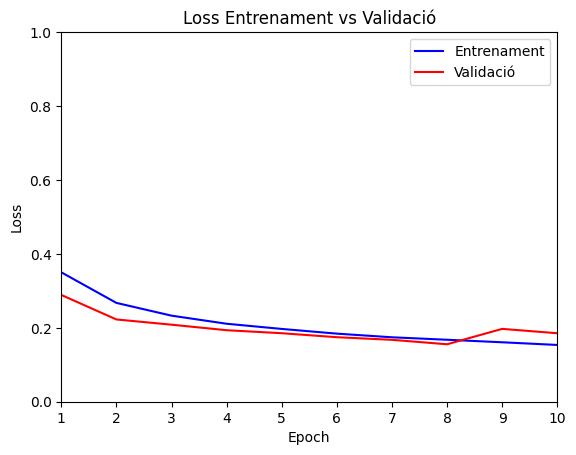

In [27]:
y_loss_train = np.array(losses)
y_loss_val = np.array(validation_losses)
epochs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

make_line_plot(epochs, y_loss_train, y_loss_val, "Loss", "Loss Entrenament vs Validació")

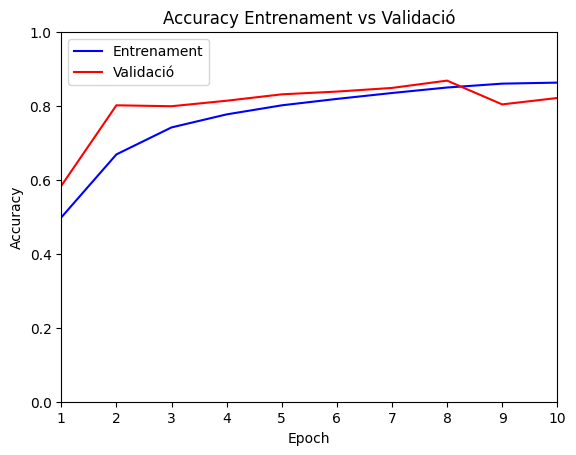

In [28]:
y_acc_train = np.array(accuracy)
y_acc_val = np.array(validation_accuracy)
epochs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

make_line_plot(epochs, y_acc_train, y_acc_val, "Accuracy", "Accuracy Entrenament vs Validació")

## Test

In [29]:
# Creació de dataset i data loader pel conjunt de test

test_d = MultiCameraDataset(
    Test_Json, 
    Test_Videos,
    transform_image_tensor
)

test_lodaer = DataLoader(
    test_d,
    batch_size=4,      # mida de batch
    shuffle=True       # barreja les dades en cada epoch
)

Maximum camera ID: 6


In [30]:
# Creació de dataset i data loader pel conjunt de test sense cutoff

test_d_no_cutoff = MultiCameraDataset(
    Test_Json, 
    Test_Videos,
    transform_image_tensor,
    max_offset=10000000000
)

test_lodaer_no_cutoff = DataLoader(
    test_d_no_cutoff,
    batch_size=4,      # mida de batch
    shuffle=True       # barreja les dades a cada epoch
)

Maximum camera ID: 6


In [31]:
for batch in test_lodaer:
    cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch
    print("Candidate frames Shape:",cand_frames.shape)
    print("Candidate Cameras ID Shape:",cand_cameras_tensor.shape)
    print("Frame Offsets Shape:",frame_offset_tensor.shape) 
    print("Past Frames Shape:",past_frames_tensor.shape)
    print("Current Camera Shape:",current_camera_tensor.shape)
    print("Selected Camera Shape:",selected_cam.shape)
    break

Candidate frames Shape: torch.Size([4, 6, 3, 224, 224])
Candidate Cameras ID Shape: torch.Size([4, 6])
Frame Offsets Shape: torch.Size([4, 15])
Past Frames Shape: torch.Size([4, 15, 3, 224, 224])
Current Camera Shape: torch.Size([4])
Selected Camera Shape: torch.Size([4])


In [32]:
print("Test with cutoffs",len(test_d))
print("Test without cutoff", len(test_d_no_cutoff))

Test with cutoffs 1087
Test without cutoff 1089


In [33]:
def test_confusion_matrix(model, dataloader, ncams= 6):

    model.eval()

    BCE_Loss_Function = nn.BCEWithLogitsLoss()

    running_loss = 0.0
    running_acc = 0
    n_samples = 0

    conf_mat = torch.zeros((ncams, ncams), dtype=torch.int32, device=device)

    with torch.no_grad():
        # Itera per cada batch
        for batch_ind, batch in enumerate(dataloader):
            # Mou a GPU
            cand_frames, cand_cameras_tensor, frame_offset_tensor, past_frames_tensor, current_camera_tensor, selected_cam = batch

            cand_frames = cand_frames.to(device)
            cand_cameras_tensor = cand_cameras_tensor.to(device)
            frame_offset_tensor = frame_offset_tensor.to(device)
            past_frames_tensor = past_frames_tensor.to(device)
            current_camera_tensor= current_camera_tensor.to(device)
            selected_cam = selected_cam.to(device)

            with torch.amp.autocast("cuda"):

                # Aplica model
                output = model(
                    cand_frames,
                    cand_cameras_tensor,
                    past_frames_tensor,
                    frame_offset_tensor,
                    current_camera_tensor
                )

                scores = output.squeeze(-1)

                targets = (cand_cameras_tensor == selected_cam.unsqueeze(1)).float()

                # Loss function
                loss = BCE_Loss_Function(scores,targets)

            l = loss.item()
            running_loss += l

            # Accuracy
            pred_idx = scores.argmax(dim=1)
            true_idx = targets.argmax(dim=1)
            correct = (pred_idx == true_idx).sum().item()

            total = scores.size(0)

            batch_acc = correct/total

            running_acc += correct
            n_samples += total

            # Confusion matrix
            pred_cam = cand_cameras_tensor[
                torch.arange(total, device=device),
                pred_idx
            ]

            for p, t in zip(pred_cam, selected_cam):
                conf_mat[t.item(), p.item()] += 1

            # Precission

            if batch_ind % 100 == 0:

                print(f"Batch {batch_ind}, loss: {l}, accuracy: {batch_acc}")

    # Average loss
    av_loss = running_loss / len(dataloader)
    av_acc = running_acc / n_samples
    print(f"Average loss = {av_loss}, average_accuracy = {av_acc}, number of samples = {n_samples}")

    # Precission
    Confusion_Matrix = conf_mat.detach().cpu()

    # Precision per-class
    precision_per_class = []
    recall_per_class = []

    f_score_per_class = []

    for i in range(ncams):
        tp = Confusion_Matrix[i, i].item()
        fp = Confusion_Matrix[:, i].sum().item() - tp
        fn = Confusion_Matrix[i, :].sum().item() - tp

        precision = tp / (tp + fp)
        precision_per_class.append(precision)

        # Recall
        recall = tp / (tp + fn)
        recall_per_class.append(recall)

        # F1 score
        f_score = 2*((precision * recall)/(precision + recall))
        f_score_per_class.append(f_score)

    # macro precision
    precision_macro = sum(precision_per_class) / ncams

    # Recall Mitjana
    mean_recall = sum(recall_per_class) / ncams

    # F1 mitjana
    mean_f_score = sum(f_score_per_class) / ncams
                
    return av_loss, av_acc, Confusion_Matrix, precision_per_class, precision_macro, recall_per_class, mean_recall, f_score_per_class, mean_f_score

## Carregant model guardat

In [34]:
#model_saved = Multi_Camera_View_Recomendation(number_cameras=12)
#model_saved.load_state_dict(torch.load("Multi_Camera_Model_State_Directory.pth"))
#model_saved = model_saved.to(device)

## Calculant  mètriques de qualitat amb el conjunt de test

In [35]:
loss_test, acc_test, c_mat, prec_per_class, prec_macro, recall_class, m_recall, f_score_class, mean_f_sc = test_confusion_matrix(m, test_lodaer)

Batch 0, loss: 0.8100029826164246, accuracy: 0.5
Batch 100, loss: 0.4346029758453369, accuracy: 0.25
Batch 200, loss: 0.6882966756820679, accuracy: 0.0
Average loss = 0.4944089854903081, average_accuracy = 0.43054277828886844, number of samples = 1087


In [36]:
def plot_conf_matrix(n):
    labels = list(range(1, n.shape[0] + 1))

    plt.figure(figsize=(7, 6))
    sns.heatmap(n, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

    plt.xlabel("Predicció")
    plt.ylabel("Veritat")
    plt.title("Matriu de confussió")

    plt.tight_layout()
    plt.show()

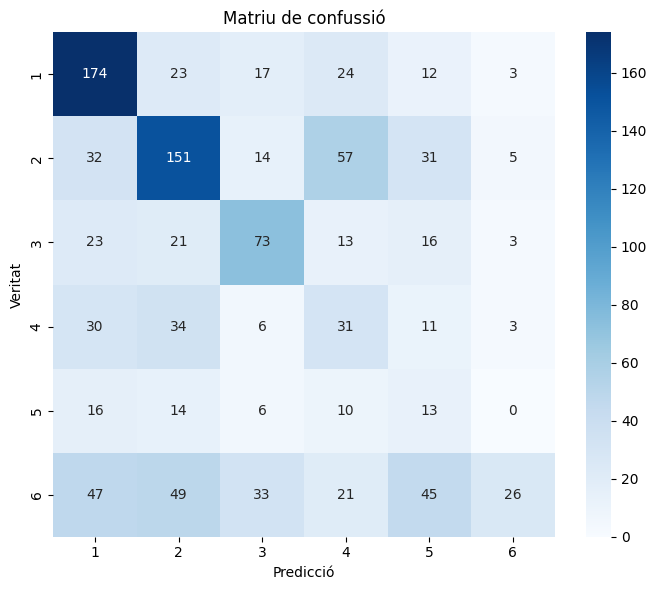

In [37]:
plot_conf_matrix(c_mat.numpy())

In [38]:
print("Precision by class",prec_per_class)
print("Average Precision:", prec_macro)

print("Recall by class",recall_class)
print("Average Recall:", m_recall)

print("F1 score by class", f_score_class)
print("Average F1 Score:", mean_f_sc)

Precision by class [0.5403726708074534, 0.5171232876712328, 0.4899328859060403, 0.1987179487179487, 0.1015625, 0.65]
Average Precision: 0.41628488218377924
Recall by class [0.6877470355731226, 0.5206896551724138, 0.4899328859060403, 0.26956521739130435, 0.22033898305084745, 0.11764705882352941]
Average Recall: 0.384320139319543
F1 score by class [0.6052173913043478, 0.5189003436426117, 0.4899328859060403, 0.22878228782287824, 0.13903743315508021, 0.1992337164750958]
Average F1 Score: 0.363517343051009


In [39]:
loss_test_no_cutoff, acc_test_no_cutoff, c_mat_no_cutoff, prec_per_class_no_cutoff, prec_macro_no_cutoff, recall_class_no_cutoff, m_recall_no_cutoff, f_score_class_no_cutoff, mean_f_sc_no_cutoff = test_confusion_matrix(m, test_lodaer_no_cutoff)

Batch 0, loss: 0.2872641086578369, accuracy: 0.75
Batch 100, loss: 0.6459062099456787, accuracy: 0.0
Batch 200, loss: 0.6093988418579102, accuracy: 0.25
Average loss = 0.4958344506638827, average_accuracy = 0.43067033976124885, number of samples = 1089


In [40]:
print("Precision by class",prec_per_class_no_cutoff)
print("Precision:", prec_macro_no_cutoff)

print("Recall by class",recall_class_no_cutoff)
print("Average Recall:", m_recall_no_cutoff)

print("F1 score by class", f_score_class_no_cutoff)
print("Average F1 Score:", mean_f_sc_no_cutoff)

Precision by class [0.5403726708074534, 0.5187713310580204, 0.4899328859060403, 0.19745222929936307, 0.1015625, 0.65]
Precision: 0.4163486028451462
Recall by class [0.6877470355731226, 0.5223367697594502, 0.4899328859060403, 0.26956521739130435, 0.21666666666666667, 0.11764705882352941]
Average Recall: 0.3839826056866856
F1 score by class [0.6052173913043478, 0.5205479452054794, 0.4899328859060403, 0.22794117647058826, 0.13829787234042554, 0.1992337164750958]
Average F1 Score: 0.3635284979503295


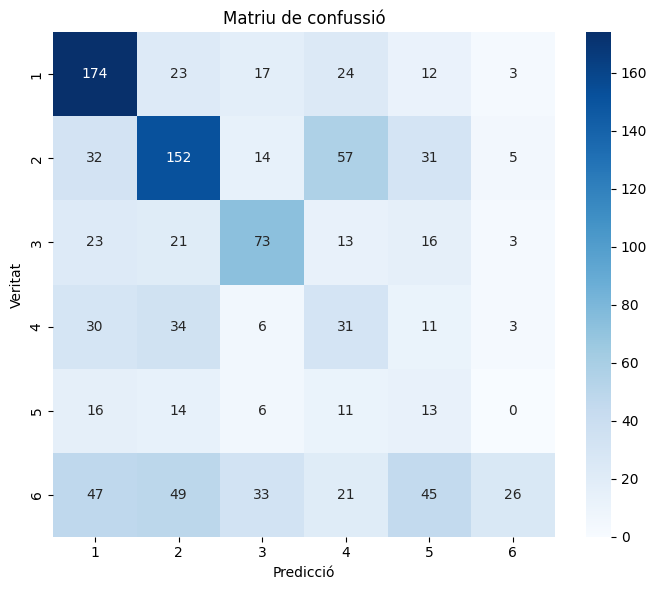

In [41]:
plot_conf_matrix(c_mat_no_cutoff.numpy())